In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [22]:
df = pd.read_csv("..\data\zomato.csv\zomato.csv")

In [23]:
df.describe()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
count,56235,56236,56233,56194,48414,56174,54956,56126,55914,28027,56049,55731,51642
unique,13397,11914,2639,2902,2877,5195,17712,2920,2961,8067,5553,2879,2783
top,('Rated 4.0',('Rated 4.0',Yes,No,NEW,0,('Rated 4.0',BTM,Quick Bites,('Rated 4.0',North Indian,300,Delivery
freq,942,300,30444,45268,2208,10027,412,5125,19132,407,2913,7576,24317


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

### Removing phone number column as it is not required for analysis

In [25]:
df['phone']

0          080 42297555\r\n+91 9743772233
1                            080 41714161
2                          +91 9663487993
3                          +91 9620009302
4        +91 8026612447\r\n+91 9901210005
                       ...               
56247                        080 40301477
56248                      +91 8197675843
56249                                 NaN
56250                        080 49652769
56251                      +91 8071117272
Name: phone, Length: 56252, dtype: object

In [26]:
df['phone'].value_counts()

 ('Rated 4.0'                            412
 ('Rated 5.0'                            393
080 43334321                             216
 ('Rated 3.0'                            181
080 43334333                             167
                                        ... 
080 26539798\r\r\n+91 7619201123           1
+91 7406666414\r\r\n+91 8880404444         1
+91 8217793626\r\r\n+91 8375867011         1
 wand                                      1
but friendly staff\nFood is good too       1
Name: phone, Length: 17712, dtype: int64

In [27]:
df2 = df.copy()

In [28]:
df2.drop(columns=['phone'], inplace=True)

### Working with 'Address' and 'Location' columns to extract useful information

In [29]:
df[['address','location']]

,address,location
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Banashankari
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Banashankari
2,"1112, Next to KIMS Medical College, 17th Cross...",Banashankari
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Banashankari
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Basavanagudi
...,...,...
56247,"Four Points by Sheraton Bengaluru, 43/3, White...",Whitefield
56248,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Whitefield
56249,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Whitefield
56250,Sheraton Grand Bengaluru Whitefield Hotel & Co...,"ITPL Main Road, Whitefield"


In [30]:
mask = df['address'].str.contains('kormangala', case=False, na=False)
result = df[mask]          # rows that match
indices = df[mask].index   # index values

In [31]:
result

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
9087,"507, 6th Block, 6th Cro6ss, Near Kormangala Cl...",7 Star Biryani,Yes,No,3.2/5,15,+91 9880532833,Koramangala 6th Block,NaN,NaN,Biryani,250,Delivery
9478,"912, 80 Feet Road 6th Block, Kormangala, BTM, ...",Cane Crussh,Yes,No,NEW,0,+91 9742134883,BTM,Beverage Shop,NaN,Juices,100,Delivery
9821,"66, Kormangala Industrial Layout, Koramangala ...",Krem,Yes,No,4.1/5,61,080 49653345,Koramangala 5th Block,Dessert Parlor,"Churros, Baklava Ice Cream, Cheesecake, Chocol...","Desserts, Ice Cream, Beverages, Sandwich",450,Delivery
9928,"Shop 88, Jyoti Nivas College Road, Kormangala ...",The Marash,Yes,No,4.3/5,62,+91 8050000164,Koramangala 5th Block,Dessert Parlor,"Turkish Ice Cream, Baklava, Chocolate Icecreams","Turkish, Desserts",250,Delivery
10612,"474, Ground Floor, 1st Cross Road, KHB Colony,...",Panwaadi,No,No,NaN,0,+91 9899443477,Koramangala 4th Block,Dessert Parlor,NaN,"Desserts, Paan",100,Delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39262,"474, Ground Floor, 1st Cross Road, KHB Colony,...",Panwaadi,No,No,NaN,0,+91 9899443477,Koramangala 4th Block,Dessert Parlor,NaN,"Desserts, Paan",100,Desserts
39286,"Nirguna Mandir Layout, ST bed, Kormangala 4th ...",Creme & Cheese,No,No,3.8 /5,18,+91 9900100460,Koramangala 4th Block,"Takeaway, Delivery",NaN,Desserts,850,Desserts
39728,"507, 6th Block, 6th Cro6ss, Near Kormangala Cl...",7 Star Biryani,Yes,No,3.2 /5,15,+91 9880532833,Koramangala 6th Block,NaN,NaN,Biryani,250,Dine-out
39834,"Near Wipro Circle, Kormangala 4th Block, Opp. ...",Sri Vishnu Upahar,No,No,3.6 /5,28,080 41306532,Koramangala 4th Block,Quick Bites,NaN,"North Indian, South Indian",250,Dine-out


In [32]:
def clean_and_match_location(df, Top_k_features):

    '''
    Cleans and matches the 'location' and 'address' columns in the dataframe.
    Steps:
    1) Clean 'location' column by removing ratings and invalid patterns.
    2) Clean 'address' column by removing newlines and invalid patterns.
    3) Extract location from cleaned address.
    4) Calculate match score between cleaned location and extracted address location.
    5) Choose final location based on match score.
    6) Group rare locations into 'Other'.
    7) Drop intermediate columns used for processing.
    Parameters:
    df (pd.DataFrame): Input dataframe with 'location' and 'address' columns.
    Top_k_features (int): Number of top locations to retain; others grouped as 'Other'.
    Returns:
    pd.DataFrame: Dataframe with cleaned and matched 'location' column.
    '''
    INVALID_PATTERNS = [
        r"\(''",         # (''  
        r"\('",          # ('  
        r"''",           # ''  
        r"\(\s*''\s*\)", # ('') or similar
    ]

    def contains_invalid_pattern(text):
        if text is None:
            return True
        text = str(text)
        for p in INVALID_PATTERNS:
            if re.search(p, text):
                return True
        return False

    # 1) CLEAN LOCATION COLUMN
    def clean_location_text(loc):
        if pd.isna(loc) or contains_invalid_pattern(loc):
            return None

        loc = str(loc)

        # remove parenthetical ratings like (Rated 4.5)
        loc = re.sub(r'\(\s*rated\s*[:\s]?\d+\.?\d*\s*\)', '', loc, flags=re.IGNORECASE)

        # remove "rated 4.5"
        loc = re.sub(r'rated\s*\d+\.?\d*', '', loc, flags=re.IGNORECASE)

        # remove "4.5/5"
        loc = re.sub(r'\d+\.?\d*\s*/\s*5\b', '', loc, flags=re.IGNORECASE)

        # remove blocks starting with RATED
        loc = re.sub(r'(?i)rated[\s\S]*', '', loc).strip()

        # normalize whitespace
        loc = re.sub(r'\s+', ' ', loc).strip()

        return loc if len(loc) > 2 else None


    df['location_cleaned'] = df['location'].apply(clean_location_text)

    
    # 2) CLEAN ADDRESS COLUMN BEFORE EXTRACTION
    def clean_address(addr):
        if pd.isna(addr) or contains_invalid_pattern(addr):
            return None
        return str(addr).replace("\n", " ").strip()

    df['address_clean'] = df['address'].apply(clean_address)

    
    # 3) EXTRACT LOCATION FROM ADDRESS
    def extract_location_from_address(addr):
        if addr is None:
            return None

        parts = [p.strip() for p in addr.split(',')]

        noise_keywords = ['karnataka', 'bangalore', 'bengaluru', 'india', 'whitefield']

        # try second-to-last component
        if len(parts) >= 2:
            candidate = parts[-2].lower()
            if not contains_invalid_pattern(candidate) \
               and not re.search(r'\d{6}', candidate) \
               and not any(n in candidate for n in noise_keywords) \
               and len(candidate) > 3:
                return candidate

        return None

    df['address_location'] = df['address_clean'].apply(extract_location_from_address)

    
    # 4) MATCH SCORE
    def calculate_match_score(row):
        loc = row['location_cleaned']
        addr = row['address_location']

        if loc is None or addr is None:
            return 0

        if loc == addr:
            return 3
        if loc in addr:
            return 2
        if len(set(loc.split()) & set(addr.split())) > 0:
            return 1

        return 0

    df['location_match_score'] = df.apply(calculate_match_score, axis=1)

    
    # 5) CHOOSE FINAL LOCATION
    def get_final_location(row):
        if row['location_cleaned'] is not None and row['location_match_score'] >= 2:
            return row['location_cleaned']
        if row['location_cleaned'] is not None:
            return row['location_cleaned']
        if row['address_location'] is not None:
            return row['address_location']
        return None

    df['location_final'] = df.apply(get_final_location, axis=1)

    # replace None with 'Unknown'
    df['location_final'] = df['location_final'].fillna('Unknown')

    
    # 6) GROUP RARE LOCATIONS
    top_n = Top_k_features
    location_counts = df['location_final'].value_counts()
    top_locations = location_counts.head(top_n).index

    df['location'] = df['location_final'].apply(
        lambda x: x if x in top_locations else 'Unknown'
    )

 
    # 7) DROP INTERMEDIATE COLUMNS
 
    df = df.drop(columns=[
        'location_cleaned',
        'address_clean',
        'address_location',
        'location_match_score',
        'location_final',
        'address'
    ])

    return df


In [33]:

df2 = clean_and_match_location(df2, Top_k_features=75)
df2['location'].value_counts()

BTM                      5125
Unknown                  4839
HSR                      2523
Koramangala 5th Block    2504
JP Nagar                 2235
                         ... 
Sadashiv Nagar             63
Sahakara Nagar             53
Koramangala                48
East Bangalore             44
Jalahalli                  38
Name: location, Length: 75, dtype: int64

### Working with 'Cuisines' column to identify popular cuisines

In [34]:
df2['cuisines'].value_counts()

North Indian                                                                                                        2913
North Indian, Chinese                                                                                               2385
South Indian                                                                                                        1828
Biryani                                                                                                              918
Bakery, Desserts                                                                                                     911
                                                                                                                    ... 
the service is a bit slow                                                                                              1
 sizzlers                                                                                                              1
 and the potion was suffice. The

In [35]:
df2['cuisines'].isnull().sum()

203

In [36]:
def map_cuisine(cuisine):
    """
    Maps cuisine strings to cuisine groups.
    - If restaurant falls into 1 group: returns that group
    - If restaurant falls into 2-3 groups: returns 'Multi-Cuisine'
    - If falls into >3 groups or no match: returns 'Other'
    """
    if pd.isnull(cuisine):
        return "Other"
        
    # Clean & split
    cuisine_list = [c.strip().lower() for c in cuisine.split(",")]
    
    # Define cuisine groups
    cuisine_groups = {
        'Indian': [
            'north indian', 'south indian', 'biryani', 'hyderabadi', 
            'mughlai', 'punjabi', 'rajasthani', 'gujarati', 'bengali',
            'kerala', 'andhra', 'chettinad', 'mangalorean', 'goan',
            'indian', 'tandoor', 'curry', 'thali'
        ],
        'Street Food': [
            'street food', 'fast food', 'chaat', 'rolls', 'momos',
            'vada pav', 'pani puri', 'dosa', 'idli'
        ],
        'Desserts & Cafe': [
            'desserts', 'mithai', 'ice cream', 'bakery', 'beverages',
            'juice', 'shakes', 'tea', 'coffee', 'sweets', 'cafe'
        ],
        'Asian': [
            'chinese', 'thai', 'japanese', 'korean', 'vietnamese',
            'asian', 'pan asian', 'sushi', 'ramen', 'noodles',
            'dimsum', 'mongolian'
        ],
        'Middle Eastern': [
            'arabian', 'lebanese', 'mediterranean', 'turkish', 'persian',
            'kebab', 'shawarma', 'falafel', 'hummus'
        ],
        'Western': [
            'italian', 'mexican', 'american', 'continental', 'european',
            'pizza', 'burger', 'sandwich', 'pasta', 'steak', 'french'
        ],
        'Specialty': [
            'seafood', 'grill', 'bbq', 'barbecue', 'fusion',
            'healthy food', 'salad', 'vegan', 'vegetarian'
        ]
    }
    
    # Find which groups this restaurant belongs to
    matched_groups = set()
    for group_name, keywords in cuisine_groups.items():
        for cuisine_item in cuisine_list:
            if cuisine_item in keywords:
                matched_groups.add(group_name)
                break
    
    # Determine output
    if len(matched_groups) == 1:
        # Single group
        return list(matched_groups)[0]
    elif 2 <= len(matched_groups) <= 3:
        # Multi-cuisine (2-3 groups)
        return 'Two-Or-Three-Cuisine'
    elif len(matched_groups) > 3:
        # Too many groups - likely noise
        return 'Multi-Cuisine'
    else:
        # No match found
        return 'Other'



In [37]:
df2 = df2.drop(df2[df2['cuisines'].isnull()].index)
# Apply
df2['cuisines'] = df2['cuisines'].apply(map_cuisine)
print(df2['cuisines'].value_counts())

Two-Or-Three-Cuisine    27170
Indian                  10305
Desserts & Cafe          6609
Other                    4986
Street Food              2039
Multi-Cuisine            1652
Western                  1466
Asian                    1343
Middle Eastern            274
Specialty                 205
Name: cuisines, dtype: int64


In [38]:
def plot_top_cuisines(df):
    vc = df['cuisines'].value_counts()
    plt.figure(figsize=(10,6))
    vc.plot.pie()
    plt.title("Top cuisines (standardized)")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

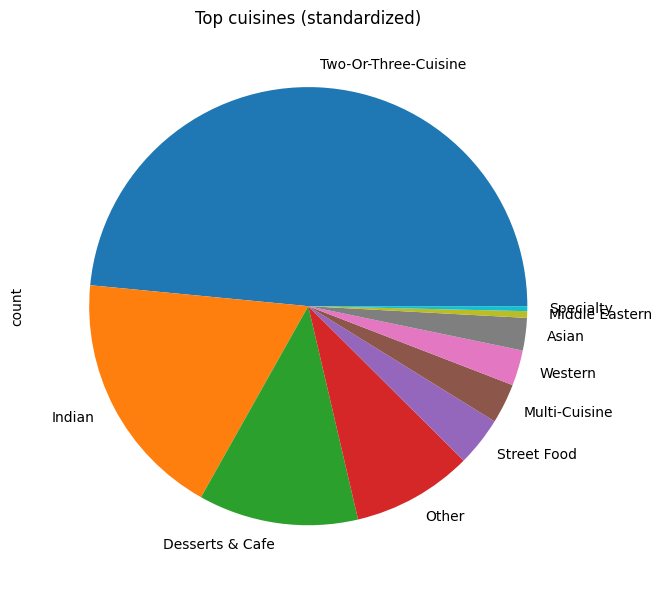

In [39]:
plot_top_cuisines(df2)

### Working on 'Listed_in(type)' column to categorize restaurant types

In [40]:
df2['listed_in(type)'].value_counts()

Delivery                                                                                                                                                                                                                     24292
Dine-out                                                                                                                                                                                                                     16240
Desserts                                                                                                                                                                                                                      3378
Cafes                                                                                                                                                                                                                         1460
Drinks & nightlife                                                                          

In [41]:
df2['listed_in(type)'].value_counts()[:7]
top7_indices = df2["listed_in(type)"].value_counts()[:7]
top7_indices

Delivery              24292
Dine-out              16240
Desserts               3378
Cafes                  1460
Drinks & nightlife      751
Buffet                  689
Pubs and bars           515
Name: listed_in(type), dtype: int64

In [47]:
df2['listed_in(type)'].value_counts()[7:].count()

2773